## IOU Analysis

In [ ]:
import os
import pandas as pd
import numpy as np
import pickle
import glob
import re


def iou_analysis(evaluation_dir,metric_type="ious"):
    # Initialize a dictionary to store results
    results = {}
    # Iterate through each model folder in the evaluation directory
    for model in os.listdir(evaluation_dir):
        if model == ".DS_Store":  # Ignore macOS system file
            continue

        model_path = os.path.join(evaluation_dir, model, 'metric_analysis')
        #ious_folder = os.path.join(model_path, iou_type)  # Path to the ious directory
        
        if os.path.isdir(model_path):  # Ensure it's a directory
            print(f"\nProcessing model: {model}")  # Debug print
            #for file in os.listdir(ious_folder):
            
            # Filter out files that contain "bious" but keep those with "ious"
            filtered_files = [file for file in glob.glob(f'{model_path}*/*/*{metric_type}.pickle') 
                  if f'/{metric_type}.pickle' in file or f'_{metric_type}.pickle' in file]

            
            #for file in glob.glob(f'{model_path}*/*/*{metric_type}.pickle'):
            for file in filtered_files:
                #if file == ".DS_Store":  # Ignore macOS system file
                #    continue

                #if file.endswith(".pkl"):  # Ensure it's a pickle file
                dataset_name = re.search(r'/([^/]+)_cvpr_NoBRS', file).group(1)  # Extract dataset name (e.g., "Berkeley")
                #file_path = os.path.join(ious_folder, file)

                # Debugging: Check if file exists
                print(f"Processing dataset: {dataset_name}, file: {file}")

                # Load IOU data
                try:
                    with open(file, "rb") as f:
                        iou_data = pickle.load(f)
                    
                    # Ensure data is a valid format (list or array of shape Nx20)
                    if isinstance(iou_data, dict) and len(iou_data) > 0:
                        # Find the maximum number of columns in the data
                        max_columns = max(len(row) for row in iou_data['all_ious'])
                        
                        # Create DataFrame with the maximum number of columns
                        df = pd.DataFrame(iou_data['all_ious'], columns=[f"{metric_type}@click{i+1}" for i in range(max_columns)])

                        # Compute mean, ignoring NaNs
                        mean_ious = df.mean(skipna=True)
                        mean_ious = df.replace([np.inf, -np.inf], np.nan).mean(skipna=True)

                        # Store results
                        if model not in results:
                            results[model] = {}
                        results[model][dataset_name] = mean_ious.values

                        print(f"Saved mean IOUs for {dataset_name} in model {model}")

                    else:
                        raise ValueError("Unexpected data format: elements are not lists or tuples.")
                        #print(f"Skipping {file}: Unexpected pickle format")

                except Exception as e:
                    print(f"Error processing {file}: {e}")
                        
    return df,results

def process_iou_analysis(results,metric_type="ious"):
    """
    Process the iou analysis
    """
    
        # Flatten the results dictionary
    flattened_results = {
        (model, dataset): values for model, datasets in results.items() for dataset, values in datasets.items()
    }

    # Create a DataFrame with a multi-level index (Model, Dataset) and appropriate columns
    df_results = pd.DataFrame.from_dict(
        flattened_results, 
        orient="index", 
        columns=[f"m{metric_type[:-1]}@click{i+1}" for i in range(20)]
    )

    # Rename index for clarity (this works now since the index is multi-level)
    df_results.index = pd.MultiIndex.from_tuples(df_results.index, names=["Model", "Dataset"])
    
    # Sorting by Dataset
    df_results_sorted = df_results.sort_index(level="Dataset")

    # Reset index to move Dataset and Model as columns
    df_results_reset = df_results_sorted.reset_index()

    # Reorganize columns to have Dataset first, followed by Model and the miou values
    df_results_reset = df_results_reset[['Dataset', 'Model'] + [f"m{metric_type[:-1]}@click{i+1}" for i in range(20)]]

    # To make the Dataset name appear only once, use `groupby` and apply `first`
    df_results_reset['Dataset'] = df_results_reset.groupby('Dataset')['Dataset'].transform('first')

    # Set Dataset and Model as the index for proper grouping
    df_results_final = df_results_reset.set_index(['Dataset', 'Model'])

    # Display the result
    return df_results, df_results_final


import matplotlib.pyplot as plt

def plot(df_results_final,datasets,metric_type="ious"):
    # Set x-axis values (clicks 1 to 20)
    clicks = [f"m{metric_type[:-1]}@click{i}" for i in range(1, 21)]

    # Plot each dataset separately
    for dataset in datasets:
        plt.figure(figsize=(10, 6))
        
        # Get all models for this dataset
        df_subset = df_results_final.loc[dataset]
        
        # Plot each model
        for model in df_subset.index:
            plt.plot(clicks, df_subset.loc[model], label=model)
        
        # Formatting
        plt.xlabel("Number of Clicks")
        plt.ylabel("Mean ")
        plt.xticks(rotation=90)
        plt.title(f"m{metric_type[:-1]} vs Clicks for {dataset}")
        plt.legend()
        plt.grid(True)
        plt.show()

### Base Models

In [37]:
datasets = ['GrabCut','Berkeley','DAVIS','PascalVOC', 'SBD','COCO_MVal', 'OAIZIB','BraTS']

#### IOU

In [33]:
metric_type = 'ious'
ious_df,ious = iou_analysis('./base_model',metric_type)
df_results, df_results_ious = process_iou_analysis(ious,metric_type)
df_results


Processing model: edge_model_50_epochs
Processing dataset: OAIZIB, file: ./base_model/edge_model_50_epochs/metric_analysis/ious/OAIZIB_cvpr_NoBRS_20_ious.pickle
Saved mean IOUs for OAIZIB in model edge_model_50_epochs
Processing dataset: Berkeley, file: ./base_model/edge_model_50_epochs/metric_analysis/ious/Berkeley_cvpr_NoBRS_20_ious.pickle
Saved mean IOUs for Berkeley in model edge_model_50_epochs
Processing dataset: BraTS, file: ./base_model/edge_model_50_epochs/metric_analysis/ious/BraTS_cvpr_NoBRS_20_ious.pickle
Saved mean IOUs for BraTS in model edge_model_50_epochs
Processing dataset: PascalVOC, file: ./base_model/edge_model_50_epochs/metric_analysis/ious/PascalVOC_cvpr_NoBRS_20_ious.pickle
Saved mean IOUs for PascalVOC in model edge_model_50_epochs
Processing dataset: COCO_MVal, file: ./base_model/edge_model_50_epochs/metric_analysis/ious/COCO_MVal_cvpr_NoBRS_20_ious.pickle
Saved mean IOUs for COCO_MVal in model edge_model_50_epochs
Processing dataset: GrabCut, file: ./base_mo

miou@click1  miou@click2  miou@click3  \
Model                Dataset                                            
edge_model_50_epochs OAIZIB        0.056285     0.145509     0.248727   
                     Berkeley      0.847148     0.917211     0.940482   
                     BraTS         0.100161     0.251464     0.420171   
                     PascalVOC     0.796756     0.889743     0.924350   
                     COCO_MVal     0.661021     0.803328     0.865434   
                     GrabCut       0.897271     0.940316     0.952887   
                     DAVIS         0.753828     0.847915     0.878094   
                     SBD           0.750700     0.846491     0.880880   
sbd_vit_base         OAIZIB        0.025174     0.082902     0.146521   
                     Berkeley      0.844146     0.912834     0.941835   
                     BraTS         0.090772     0.194545     0.366729   
                     PascalVOC     0.784857     0.876632     0.914878   
                     COCO_MVal     0.610328     0.767697     0.837586   
                     GrabCut       0.894094     0.937240     0.952339   
                     DAVIS         0.760170     0.853285     0.883353   
                     SBD           0.742834     0.836066     0.873574   

                                miou@click4  miou@click5  miou@click6  \
Model                Dataset                                            
edge_model_50_epochs OAIZIB        0.325815     0.404079     0.472416   
                     Berkeley      0.948865     0.952232     0.954350   
                     BraTS         0.568539     0.669051     0.733923   
                     PascalVOC     0.944029     0.956288     0.963539   
                     COCO_MVal     0.894853     0.916867     0.931213   
                     GrabCut       0.960116     0.967821     0.973008   
                     DAVIS         0.892159     0.901337     0.904559   
                     SBD           0.898780     0.909443     0.915633   
sbd_vit_base         OAIZIB        0.223480     0.300391     0.354647   
                     Berkeley      0.948072     0.952335     0.954153   
                     BraTS         0.507690     0.621047     0.702154   
                     PascalVOC     0.936196     0.949901     0.958541   
                     COCO_MVal     0.878300     0.903665     0.923616   
                     GrabCut       0.960570     0.968249     0.976092   
                     DAVIS         0.895459     0.899938     0.903729   
                     SBD           0.893254     0.904940     0.912537   

                                miou@click7  miou@click8  miou@click9  \
Model                Dataset                                            
edge_model_50_epochs OAIZIB        0.533137     0.575200     0.623556   
                     Berkeley      0.956211     0.956913     0.957917   
                     BraTS         0.781938     0.815574     0.839780   
                     PascalVOC     0.968844     0.973227     0.975978   
                     COCO_MVal     0.938919     0.944751     0.948746   
                     GrabCut       0.977170     0.979148     0.980031   
                     DAVIS         0.907437     0.911151     0.913245   
                     SBD           0.920168     0.923582     0.925812   
sbd_vit_base         OAIZIB        0.417386     0.473788     0.530115   
                     Berkeley      0.956872     0.957991     0.958959   
                     BraTS         0.756736     0.794532     0.819834   
                     PascalVOC     0.965035     0.969494     0.972904   
                     COCO_MVal     0.931613     0.939290     0.945216   
                     GrabCut       0.978919     0.981826     0.983529   
                     DAVIS         0.908333     0.911411     0.914440   
                     SBD           0.917665     0.921648     0.924348   

                                miou@click10  miou@click11  miou@click12  \
Model      

In [29]:
# # Extracting the miou@click10 values for the Berkeley dataset
# oaizib_miou_click = df_results_ious.loc['OAIZIB', ['miou@click3', 'miou@click10', 'miou@click20']]

# # Display the result
# oaizib_miou_click

# # Extracting the miou@click10 values for the Berkeley dataset
# brats_miou_click = df_results_ious.loc['BraTS', ['miou@click3', 'miou@click10', 'miou@click20']]

# # Display the result
# brats_miou_click

# df_results_ious.loc['BraTS']

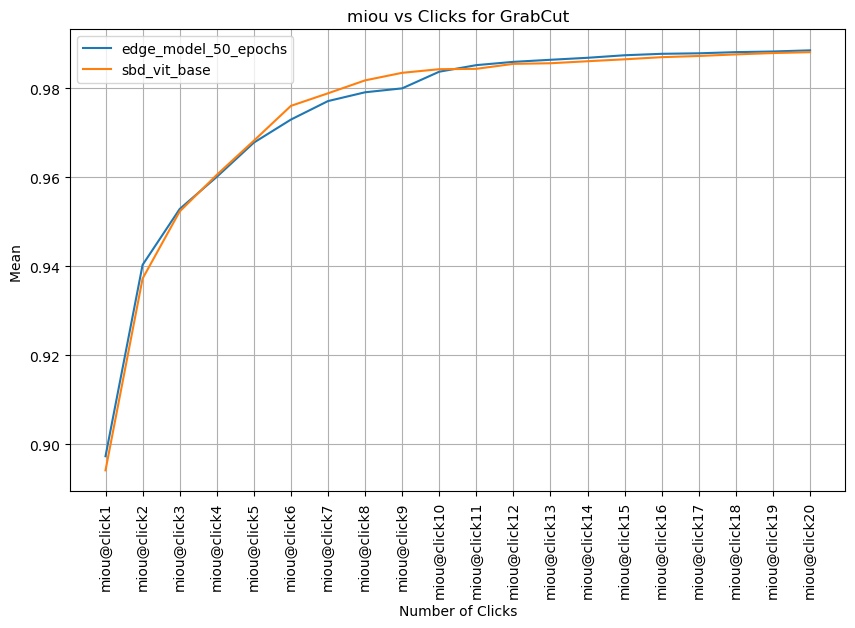

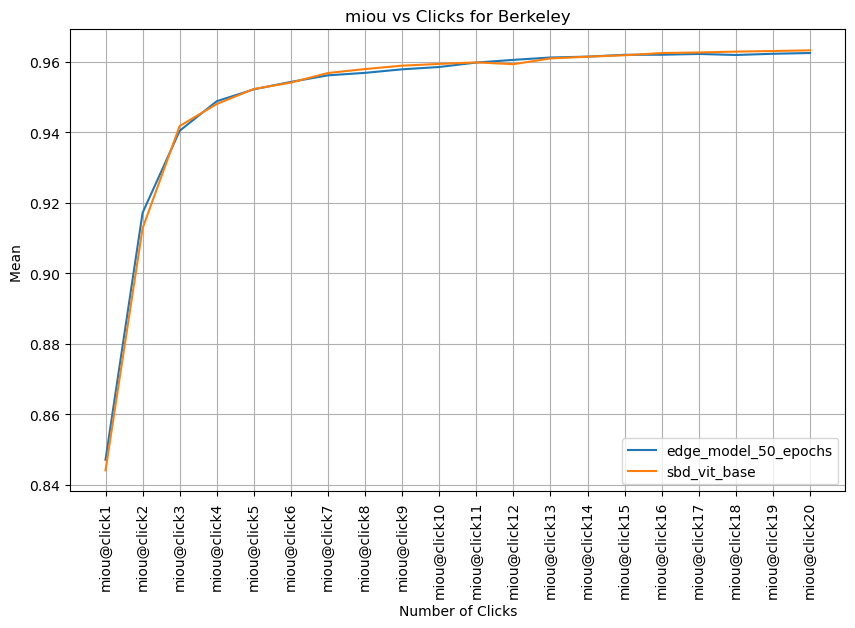

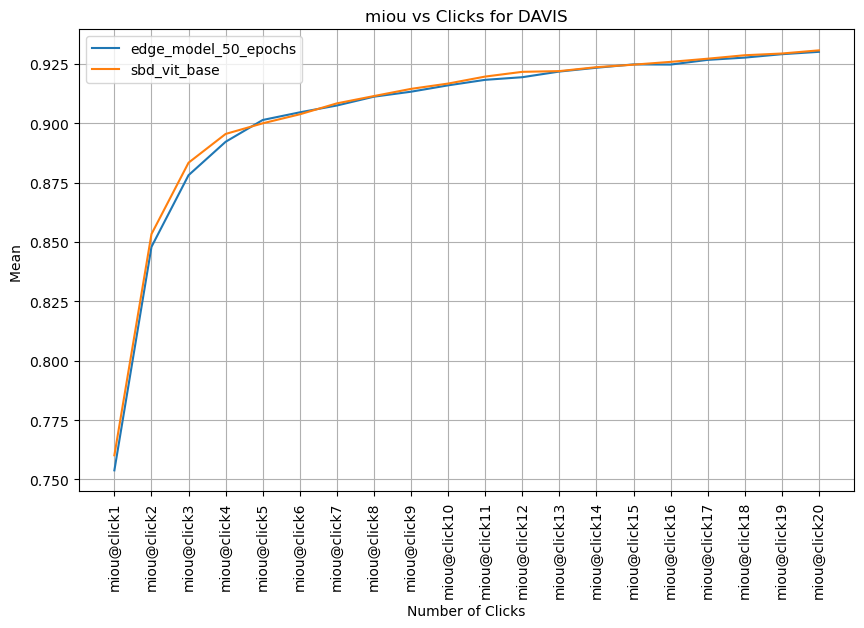

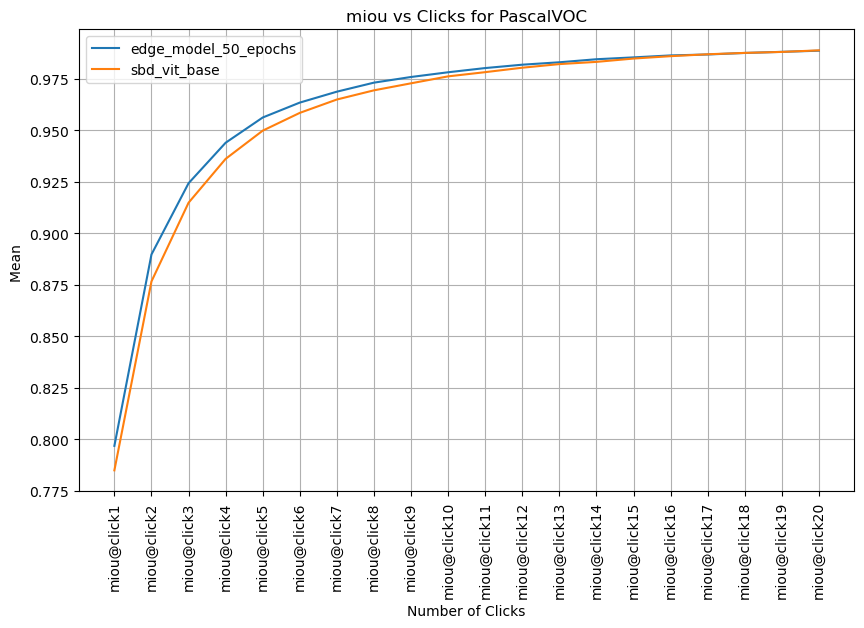

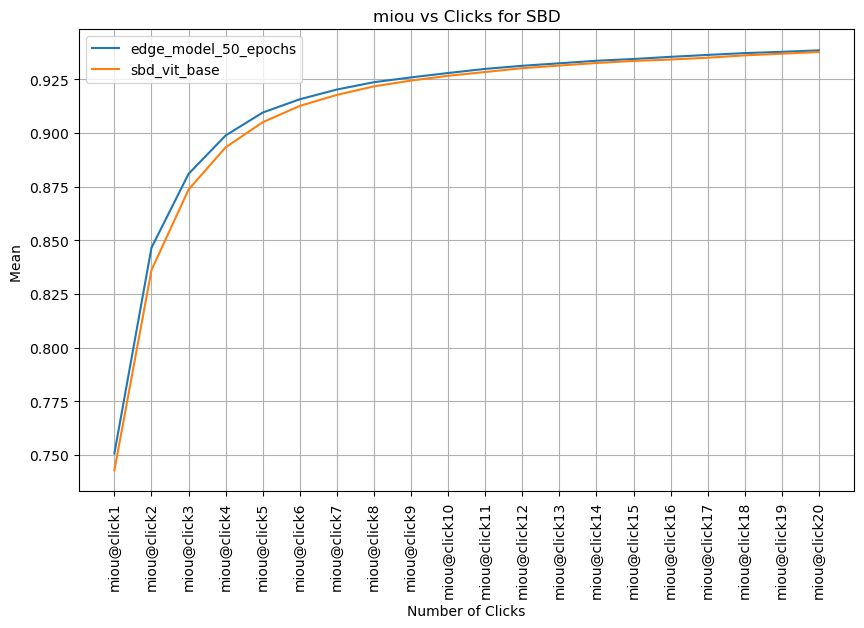

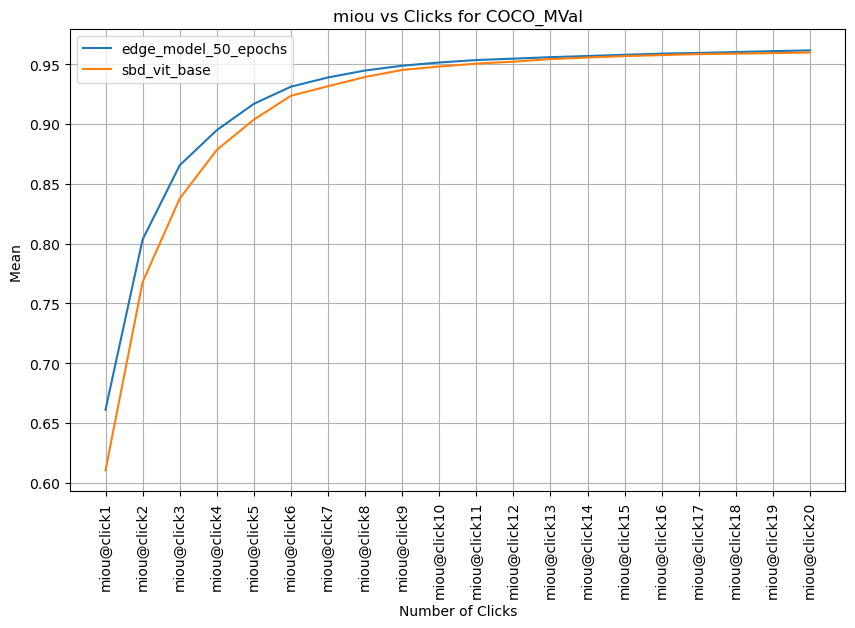

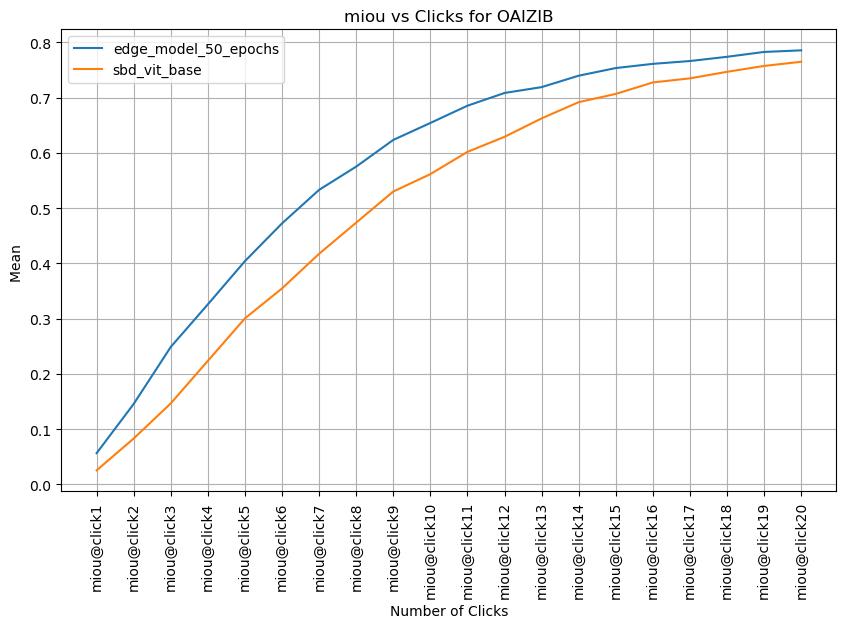

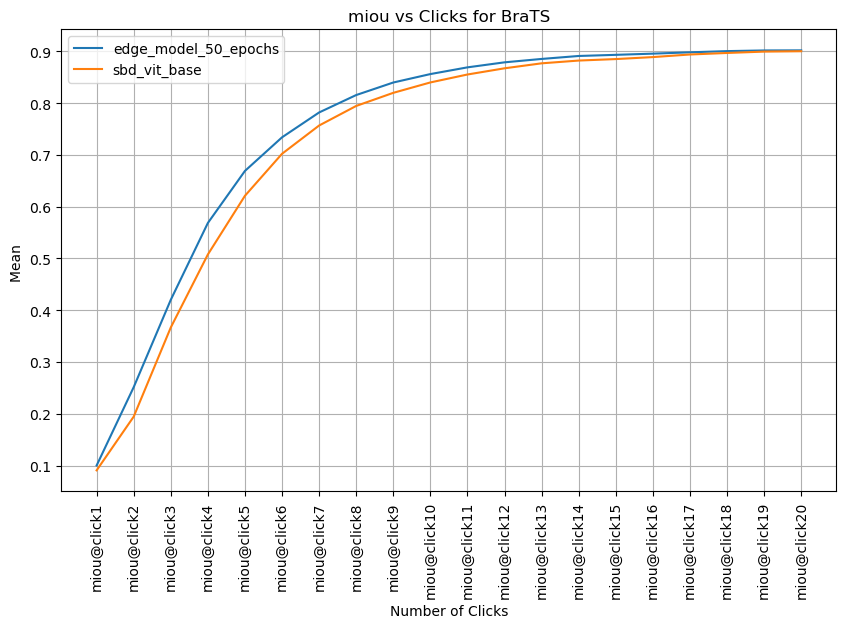

In [34]:
# Get unique dataset names
#datasets = df_results_final.index.get_level_values(0).unique()
plot(df_results_ious,datasets,metric_type)

#### Boundary IOU

In [49]:
metric_type="bious"
bious_df,bious = iou_analysis('./base_model',metric_type)
df_results_bious, df_results_final_bious = process_iou_analysis(bious,metric_type)
df_results_bious


Processing model: edge_model_50_epochs
Processing dataset: OAIZIB, file: ./base_model/edge_model_50_epochs/metric_analysis/bious/OAIZIB_cvpr_NoBRS_20_bious.pickle
Saved mean IOUs for OAIZIB in model edge_model_50_epochs
Processing dataset: PascalVOC, file: ./base_model/edge_model_50_epochs/metric_analysis/bious/PascalVOC_cvpr_NoBRS_20_bious.pickle
Saved mean IOUs for PascalVOC in model edge_model_50_epochs
Processing dataset: SBD, file: ./base_model/edge_model_50_epochs/metric_analysis/bious/SBD_cvpr_NoBRS_20_bious.pickle
Saved mean IOUs for SBD in model edge_model_50_epochs
Processing dataset: GrabCut, file: ./base_model/edge_model_50_epochs/metric_analysis/bious/GrabCut_cvpr_NoBRS_20_bious.pickle
Saved mean IOUs for GrabCut in model edge_model_50_epochs
Processing dataset: COCO_MVal, file: ./base_model/edge_model_50_epochs/metric_analysis/bious/COCO_MVal_cvpr_NoBRS_20_bious.pickle
Saved mean IOUs for COCO_MVal in model edge_model_50_epochs
Processing dataset: Berkeley, file: ./base_

mbiou@click1  mbiou@click2  mbiou@click3  \
Model                Dataset                                               
edge_model_50_epochs OAIZIB         0.045185      0.139303      0.239646   
                     PascalVOC      0.393585      0.491273      0.530960   
                     SBD            0.468687      0.588173      0.636703   
                     GrabCut        0.638531      0.709436      0.742650   
                     COCO_MVal      0.396114      0.545421      0.628711   
                     Berkeley       0.576738      0.667182      0.716385   
                     BraTS          0.022381      0.055804      0.121163   
                     DAVIS          0.534828      0.644786      0.683675   
sbd_vit_base         OAIZIB         0.012370      0.074316      0.136123   
                     PascalVOC      0.390286      0.482127      0.524633   
                     SBD            0.460796      0.575170      0.626279   
                     GrabCut        0.617896      0.702076      0.739774   
                     COCO_MVal      0.358107      0.505621      0.594657   
                     Berkeley       0.555555      0.659333      0.714938   
                     BraTS          0.018502      0.038591      0.097165   
                     DAVIS          0.528356      0.640781      0.679599   

                                mbiou@click4  mbiou@click5  mbiou@click6  \
Model                Dataset                                               
edge_model_50_epochs OAIZIB         0.316625      0.398003      0.467196   
                     PascalVOC      0.556346      0.572614      0.583840   
                     SBD            0.667553      0.688320      0.702695   
                     GrabCut        0.769177      0.792162      0.802951   
                     COCO_MVal      0.678560      0.714976      0.741689   
                     Berkeley       0.738693      0.752688      0.761869   
                     BraTS          0.205977      0.290210      0.359475   
                     DAVIS          0.705982      0.723547      0.733640   
sbd_vit_base         OAIZIB         0.215114      0.294273      0.350601   
                     PascalVOC      0.550415      0.567953      0.580426   
                     SBD            0.658433      0.680179      0.696526   
                     GrabCut        0.771183      0.793152      0.801431   
                     COCO_MVal      0.654737      0.695774      0.726910   
                     Berkeley       0.735541      0.751095      0.761114   
                     BraTS          0.166350      0.246500      0.321059   
                     DAVIS          0.701992      0.716652      0.726940   

                                mbiou@click7  mbiou@click8  mbiou@click9  \
Model                Dataset                                               
edge_model_50_epochs OAIZIB         0.528061      0.569479      0.618848   
                     PascalVOC      0.592183      0.599088      0.604422   
                     SBD            0.714725      0.724483      0.732012   
                     GrabCut        0.810257      0.820219      0.822128   
                     COCO_MVal      0.758296      0.772676      0.783692   
                     Berkeley       0.773485      0.780338      0.785546   
                     BraTS          0.421773      0.472657      0.517595   
                     DAVIS          0.743603      0.751411      0.757201   
sbd_vit_base         OAIZIB         0.413125      0.467655      0.521643   
                     PascalVOC      0.590260      0.597039      0.602679   
                     SBD            0.708792      0.719182      0.727615   
                     GrabCut        0.812843      0.823792      0.831399   
                     COCO_MVal      0.748086      0.763037      0.775810   
                     Berkeley       0.772794      0.779823      0.788943   
                     BraTS          0.387726      0.439320      0.480806   
  

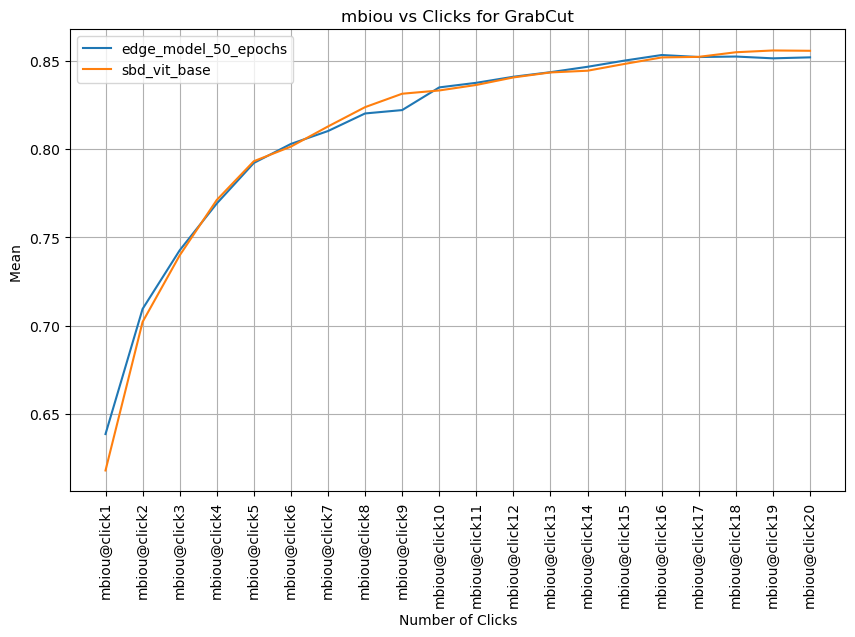

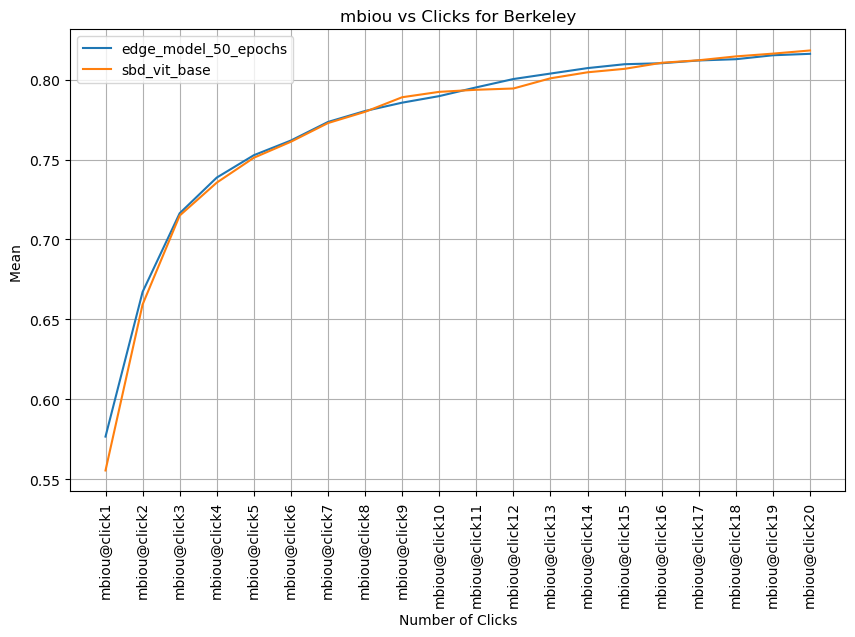

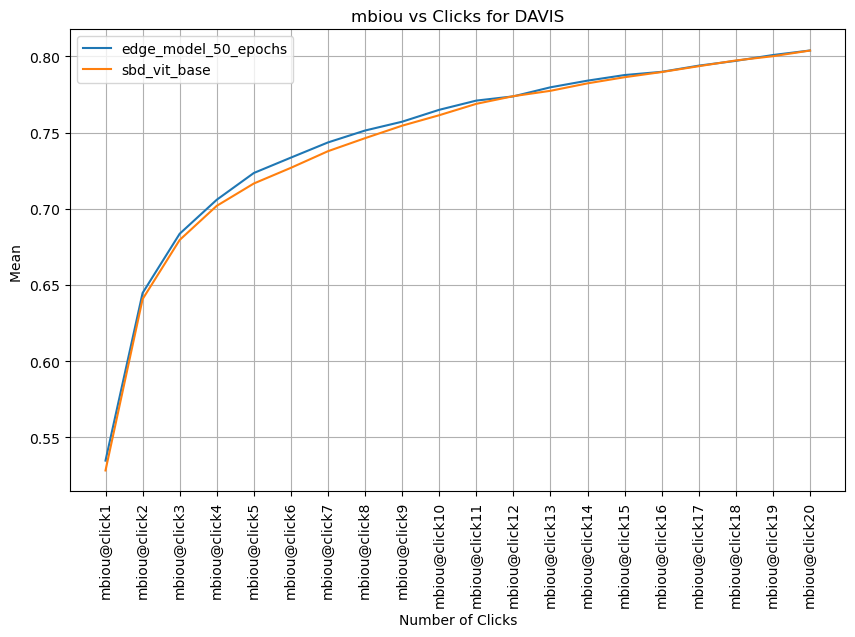

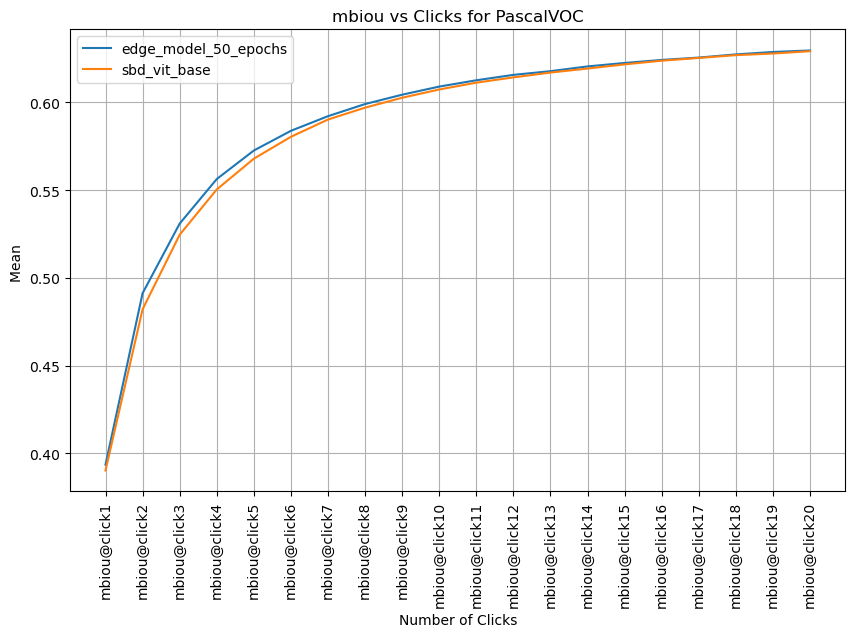

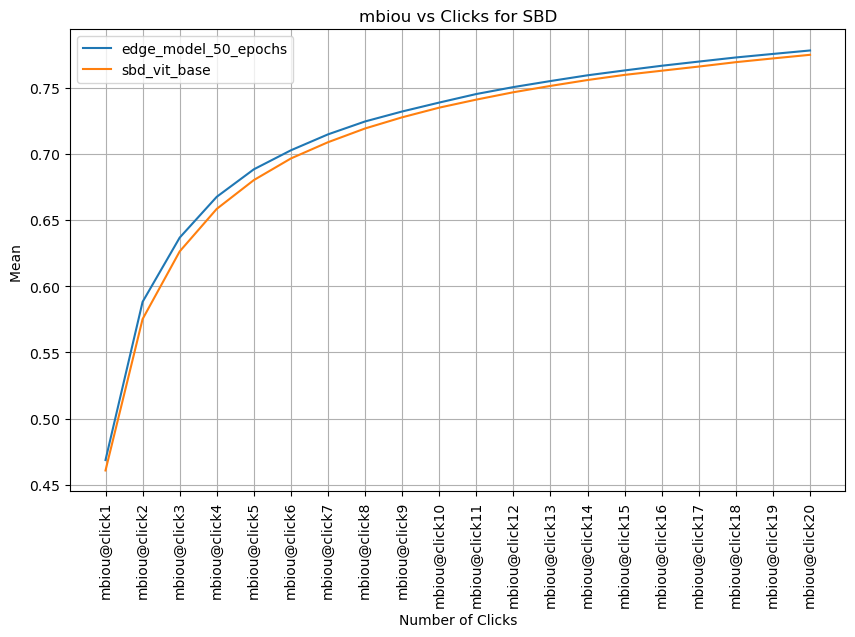

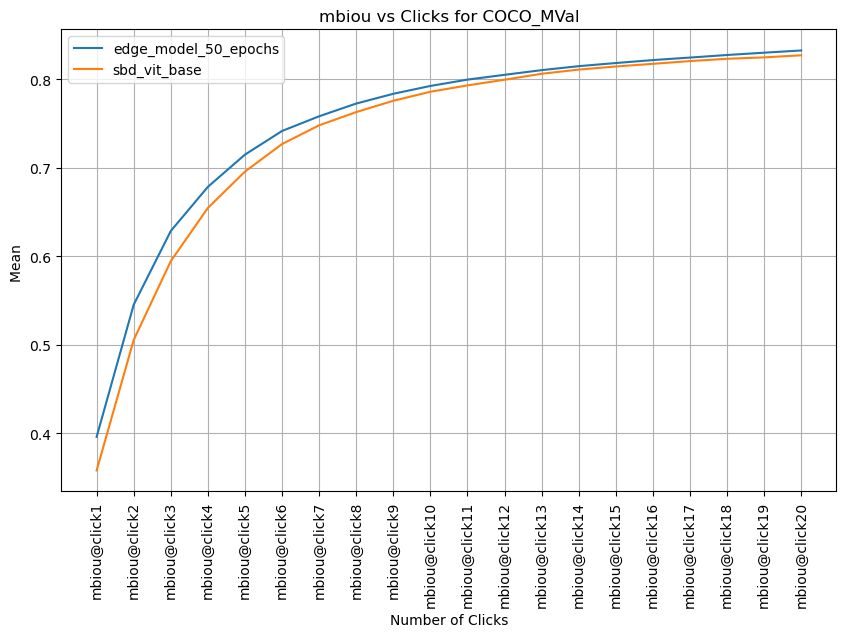

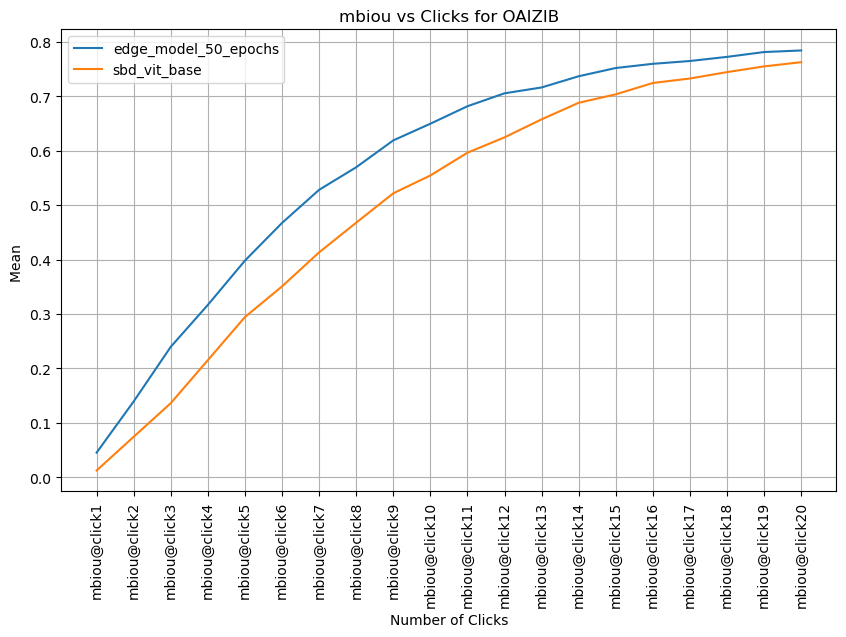

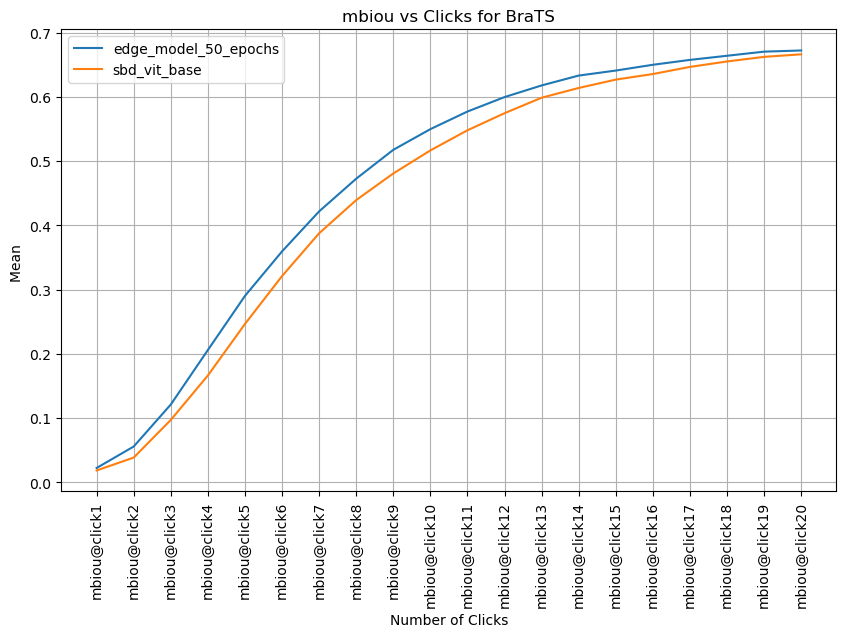

In [48]:
# Get unique dataset names
#datasets = df_results_final.index.get_level_values(0).unique()
plot(df_results_final_bious,datasets,metric_type)

#### Hausdorff Distance(HD)

In [40]:
metric_type="hds"
hd_df,hd = iou_analysis('./base_model', metric_type)
df_results_hd, df_results_final_hd = process_iou_analysis(hd,metric_type)
df_results_hd


Processing model: edge_model_50_epochs
Processing dataset: SBD, file: ./base_model/edge_model_50_epochs/metric_analysis/hds/SBD_cvpr_NoBRS_20_hds.pickle
Saved mean IOUs for SBD in model edge_model_50_epochs
Processing dataset: COCO_MVal, file: ./base_model/edge_model_50_epochs/metric_analysis/hds/COCO_MVal_cvpr_NoBRS_20_hds.pickle
Saved mean IOUs for COCO_MVal in model edge_model_50_epochs
Processing dataset: PascalVOC, file: ./base_model/edge_model_50_epochs/metric_analysis/hds/PascalVOC_cvpr_NoBRS_20_hds.pickle
Saved mean IOUs for PascalVOC in model edge_model_50_epochs
Processing dataset: DAVIS, file: ./base_model/edge_model_50_epochs/metric_analysis/hds/DAVIS_cvpr_NoBRS_20_hds.pickle
Saved mean IOUs for DAVIS in model edge_model_50_epochs
Processing dataset: OAIZIB, file: ./base_model/edge_model_50_epochs/metric_analysis/hds/OAIZIB_cvpr_NoBRS_20_hds.pickle
Saved mean IOUs for OAIZIB in model edge_model_50_epochs
Processing dataset: GrabCut, file: ./base_model/edge_model_50_epochs/

mhd@click1  mhd@click2  mhd@click3  \
Model                Dataset                                         
edge_model_50_epochs SBD         45.047661   25.274857   17.465157   
                     COCO_MVal  111.424873   53.263748   30.005993   
                     PascalVOC   49.419777   31.935986   25.420813   
                     DAVIS       88.865242   67.151260   55.772831   
                     OAIZIB     182.193527  140.329941  105.690834   
                     GrabCut     51.614639   32.577591   21.130310   
                     BraTS       91.581955   73.461174   45.359745   
                     Berkeley    46.681484   29.452330   19.473330   
sbd_vit_base         SBD         48.765106   27.310696   18.862732   
                     COCO_MVal  135.272903   70.816109   40.325615   
                     PascalVOC   52.748158   34.352062   27.142225   
                     DAVIS       89.061325   66.546364   53.384014   
                     OAIZIB     216.369812  174.260590  142.422501   
                     GrabCut     51.017960   31.481379   20.874025   
                     BraTS       92.914635   78.296768   53.292614   
                     Berkeley    49.592358   29.954863   20.134453   

                                mhd@click4  mhd@click5  mhd@click6  \
Model                Dataset                                         
edge_model_50_epochs SBD         13.652598   11.420596   10.230811   
                     COCO_MVal   19.934143   13.226327   10.015923   
                     PascalVOC   21.830750   19.463642   17.846636   
                     DAVIS       48.652271   45.914040   43.325150   
                     OAIZIB      79.056374   63.234825   54.459602   
                     GrabCut     17.496447   15.174852   14.186628   
                     BraTS       27.312218   17.045679   12.506757   
                     Berkeley    14.428162   13.129277   11.636078   
sbd_vit_base         SBD         14.571695   12.163792   10.754546   
                     COCO_MVal   26.480650   18.768795   12.092683   
                     PascalVOC   23.138874   20.401440   18.868956   
                     DAVIS       48.969860   44.907070   41.976059   
                     OAIZIB     111.714661   86.212677   76.973946   
                     GrabCut     16.906370   16.109970   14.352501   
                     BraTS       35.240429   22.067110   14.801599   
                     Berkeley    15.807778   13.592193   12.101926   

                                mhd@click7  mhd@click8  mhd@click9  \
Model                Dataset                                         
edge_model_50_epochs SBD          9.333904    8.653300    8.150604   
                     COCO_MVal    7.683350    5.592581    5.153193   
                     PascalVOC   16.858274   16.157360   15.707232   
                     DAVIS       40.830643   39.906773   39.107349   
                     OAIZIB      43.429825   35.504261   27.652348   
                     GrabCut     14.077388   11.943805   12.015198   
                     BraTS        9.150483    7.101957    5.907653   
                     Berkeley    10.959757   10.249143    9.522344   
sbd_vit_base         SBD          9.688332    8.973005    8.450165   
                     COCO_MVal    9.620605    7.722633    5.508990   
                     PascalVOC   17.502581   16.616953   16.044058   
                     DAVIS       40.557163   39.629414   38.031296   
                     OAIZIB      61.473003   51.025684   41.913681   
                     GrabCut     13.241839    8.058165    7.033888   
                     BraTS       10.214190    8.258905    6.511479   
                     Berkeley    11.327795   10.373256    9.014903   

                                mhd@click10  mhd@click11  mhd@click12  \
Model                Dataset                                            
edge_model_50_epochs SBD           7.802012     7.526947     7.257579   
                     COCO_MVal

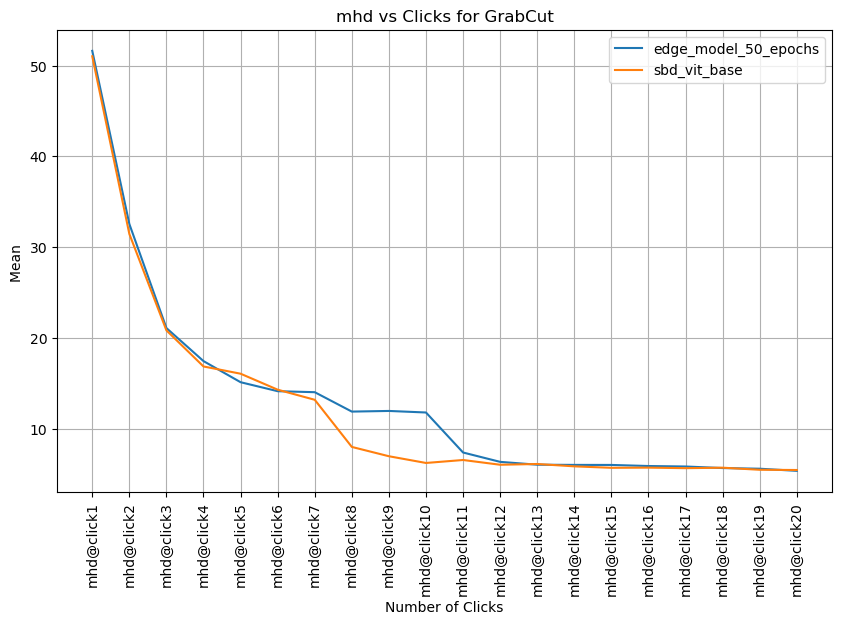

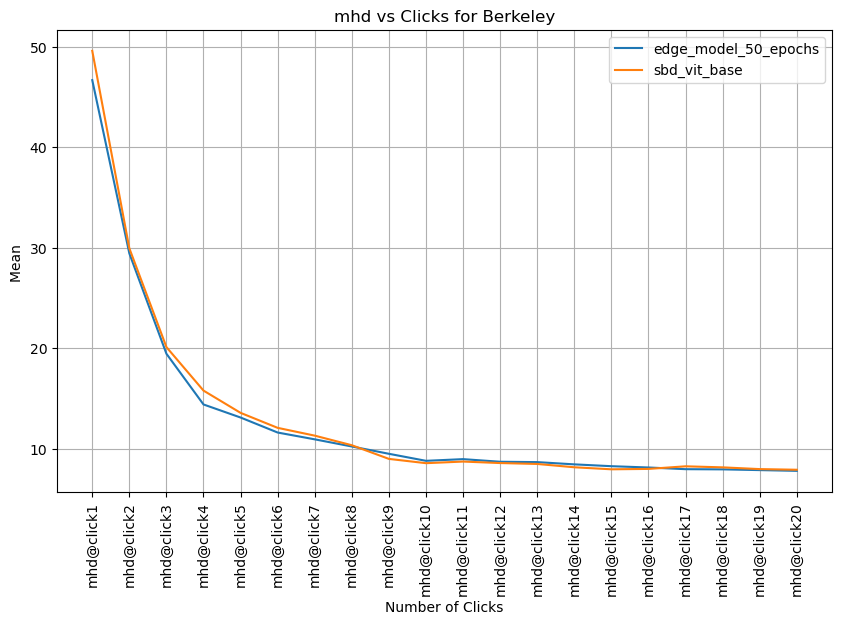

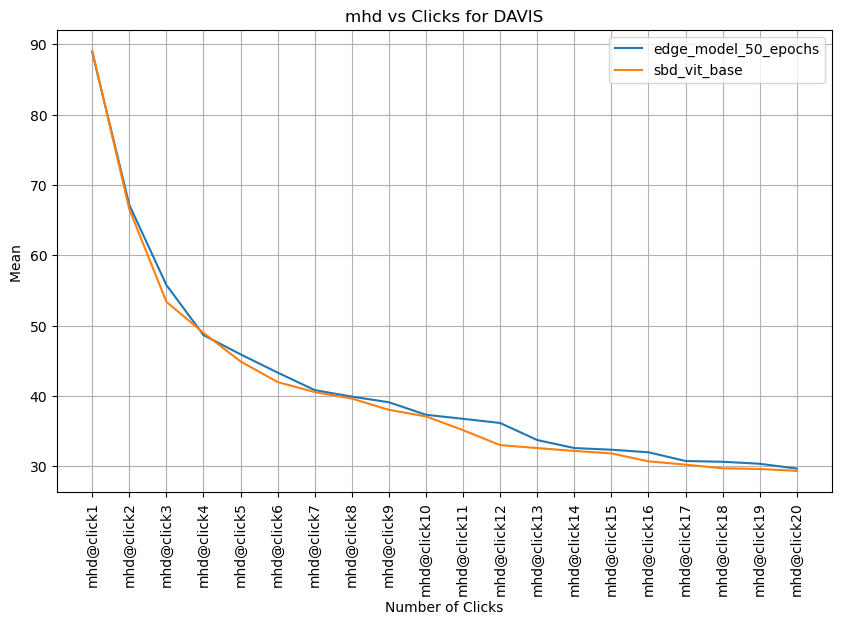

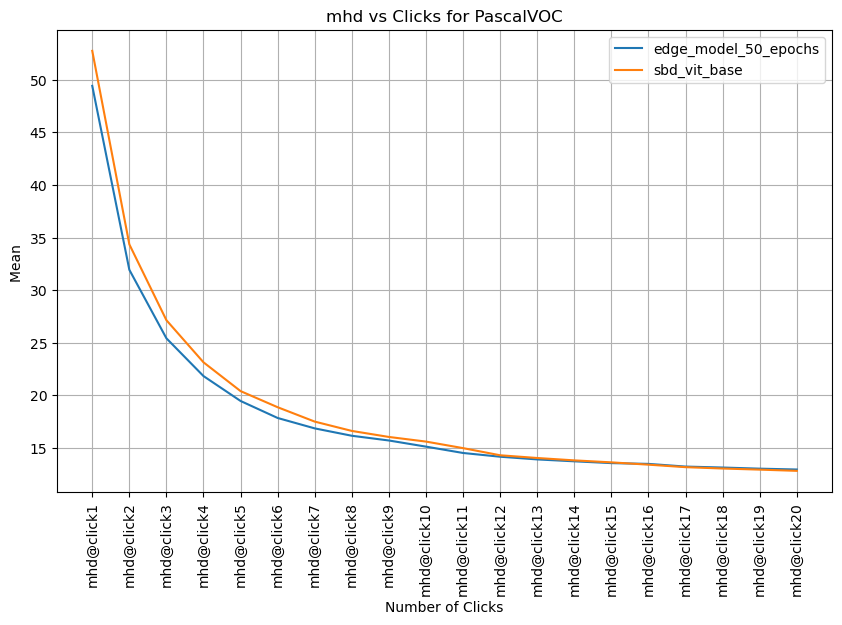

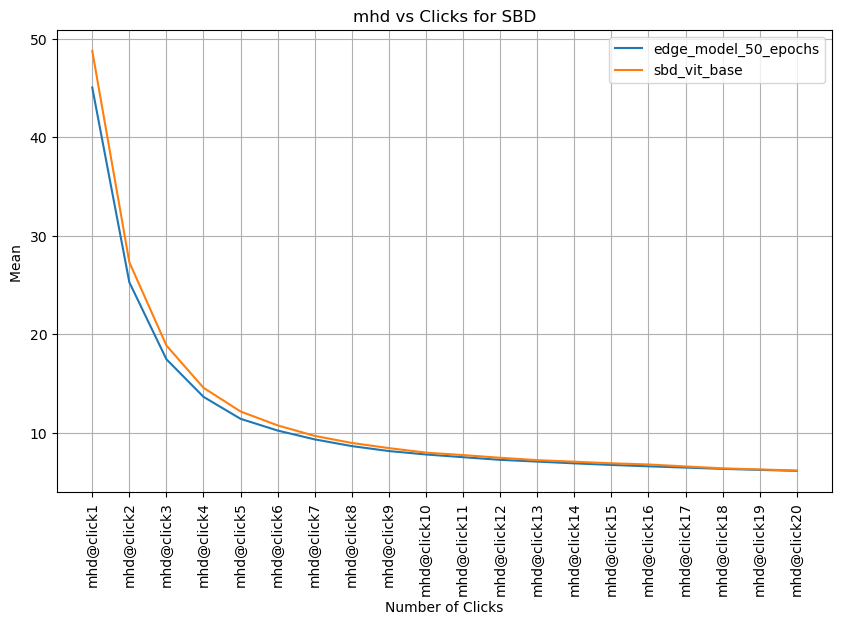

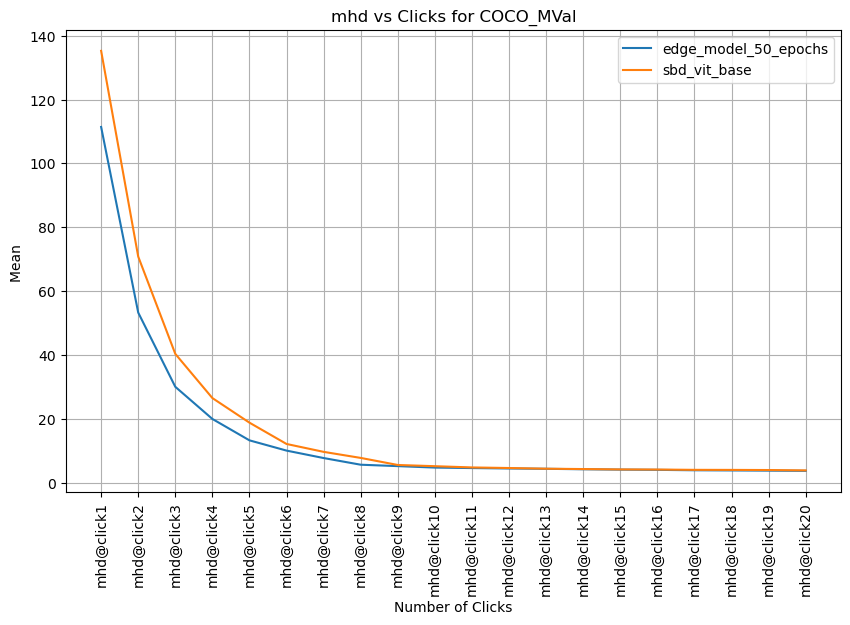

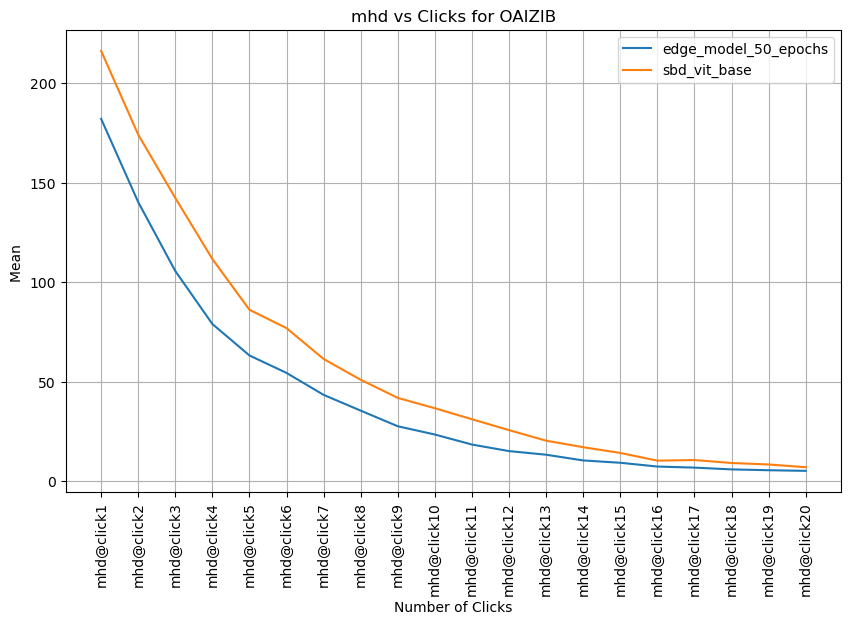

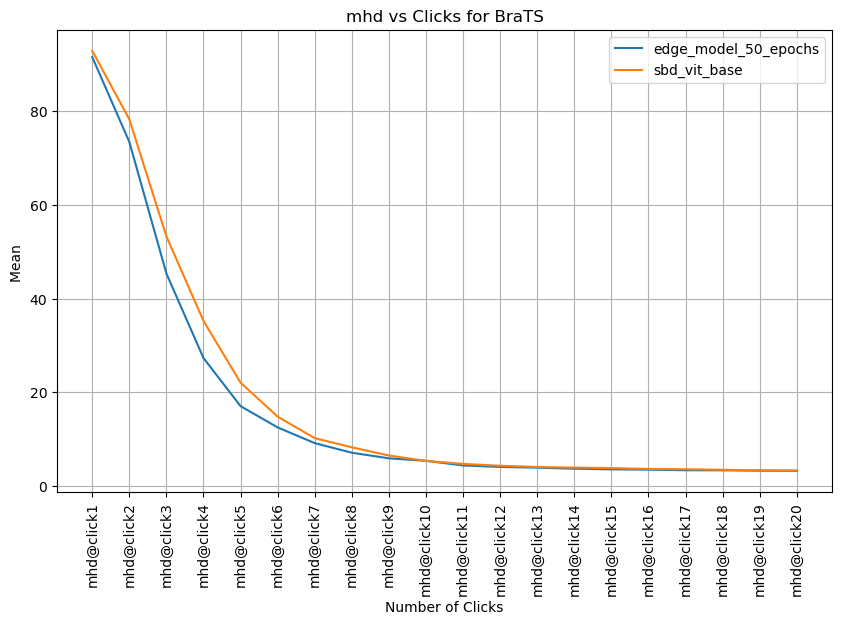

In [41]:
# Get unique dataset names
#datasets = df_results_final.index.get_level_values(0).unique()
plot(df_results_final_hd,datasets,metric_type)

#### Average Surface Distance(ASD)

In [24]:
metric_type="asds"
asd_df,asd = iou_analysis('./base_model',metric_type)
df_results_asd, df_results_final_asd = process_iou_analysis(asd,metric_type)
df_results_asd


Processing model: edge_model_50_epochs
Processing dataset: GrabCut, file: ./base_model/edge_model_50_epochs/metric_analysis/asds/GrabCut_cvpr_NoBRS_20_asds.pickle
Saved mean IOUs for GrabCut in model edge_model_50_epochs
Processing dataset: COCO_MVal, file: ./base_model/edge_model_50_epochs/metric_analysis/asds/COCO_MVal_cvpr_NoBRS_20_asds.pickle
Saved mean IOUs for COCO_MVal in model edge_model_50_epochs
Processing dataset: DAVIS, file: ./base_model/edge_model_50_epochs/metric_analysis/asds/DAVIS_cvpr_NoBRS_20_asds.pickle
Saved mean IOUs for DAVIS in model edge_model_50_epochs
Processing dataset: SBD, file: ./base_model/edge_model_50_epochs/metric_analysis/asds/SBD_cvpr_NoBRS_20_asds.pickle
Saved mean IOUs for SBD in model edge_model_50_epochs
Processing dataset: BraTS, file: ./base_model/edge_model_50_epochs/metric_analysis/asds/BraTS_cvpr_NoBRS_20_asds.pickle
Saved mean IOUs for BraTS in model edge_model_50_epochs
Processing dataset: Berkeley, file: ./base_model/edge_model_50_epoch

masd@click1  masd@click2  masd@click3  \
Model                Dataset                                            
edge_model_50_epochs GrabCut       8.632867     5.200421     3.095261   
                     COCO_MVal    37.244740    16.266636     8.433468   
                     DAVIS         4.680017     2.219220     1.718657   
                     SBD           8.823482     4.153377     2.614875   
                     BraTS        52.188835    35.595688    19.967184   
                     Berkeley      6.117119     2.949714     1.167211   
                     OAIZIB       85.840027    57.838257    35.444763   
                     PascalVOC     9.034908     4.448592     3.340031   
sbd_vit_base         GrabCut       8.880267     5.231658     3.125116   
                     COCO_MVal    50.162918    24.409191    13.016516   
                     DAVIS         5.197488     2.033176     1.740242   
                     SBD          10.973351     4.969571     3.108073   
                     BraTS        54.312954    40.803703    24.533611   
                     Berkeley      7.511882     3.340318     1.036401   
                     OAIZIB      116.893341    80.474091    59.025322   
                     PascalVOC    11.100957     5.655776     4.000014   

                                masd@click4  masd@click5  masd@click6  \
Model                Dataset                                            
edge_model_50_epochs GrabCut       2.692172     2.003569     1.865169   
                     COCO_MVal     5.766261     3.196085     2.401274   
                     DAVIS         1.435447     1.270255     1.254907   
                     SBD           1.910766     1.575420     1.422570   
                     BraTS        10.862392     6.094002     4.397839   
                     Berkeley      0.939947     0.885801     0.849257   
                     OAIZIB       20.323446    12.997158     9.593451   
                     PascalVOC     2.612110     2.308945     2.196678   
sbd_vit_base         GrabCut       2.545303     2.042151     1.618281   
                     COCO_MVal     8.141291     5.311485     3.120967   
                     DAVIS         1.443988     1.333597     1.269443   
                     SBD           2.185652     1.797274     1.571635   
                     BraTS        14.437528     8.275220     5.149085   
                     Berkeley      0.946694     0.874803     0.844632   
                     OAIZIB       39.500458    25.530977    20.017355   
                     PascalVOC     3.198447     2.713010     2.439488   

                                masd@click7  masd@click8  masd@click9  \
Model                Dataset                                            
edge_model_50_epochs GrabCut       1.442862     1.334933     1.306842   
                     COCO_MVal     1.606488     1.208822     1.117330   
                     DAVIS         1.165797     1.127172     1.117424   
                     SBD           1.294551     1.210136     1.153560   
                     BraTS         2.782731     2.053570     1.592977   
                     Berkeley      0.810693     0.792086     0.775821   
                     OAIZIB        5.700528     3.900444     3.183905   
                     PascalVOC     2.142137     2.036288     2.003177   
sbd_vit_base         GrabCut       1.307557     1.254918     1.210122   
                     COCO_MVal     2.637338     2.045398     1.192973   
                     DAVIS         1.209461     1.155231     1.096087   
                     SBD           1.421657     1.299067     1.234491   
                     BraTS         3.271627     2.342671     1.678346   
                     Berkeley      0.806035     0.783586     0.754641   
                     OAIZIB       12.842739     9.842068     6.795654   
                     PascalVOC     2.314713     2.240268     2.176568   

                                masd@click10  masd@click11  masd@click12  \
Model      

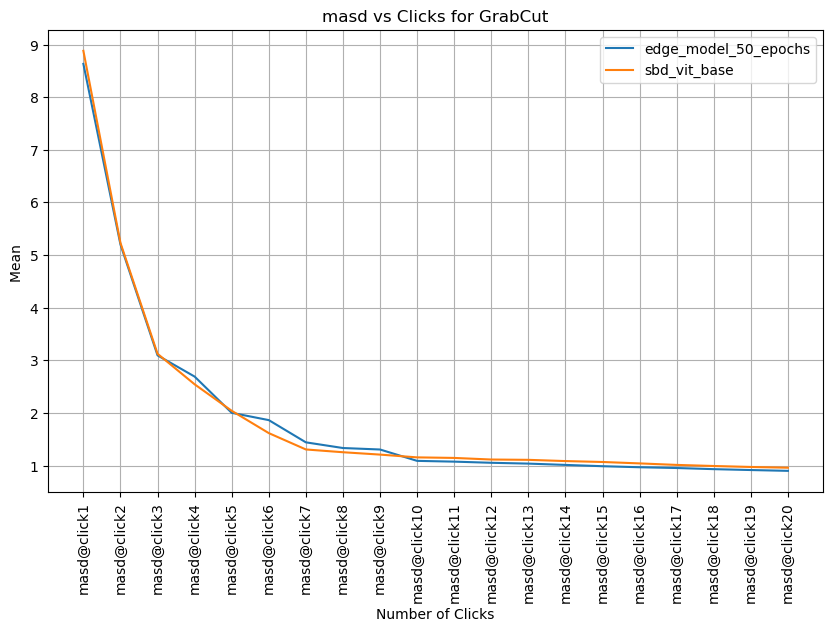

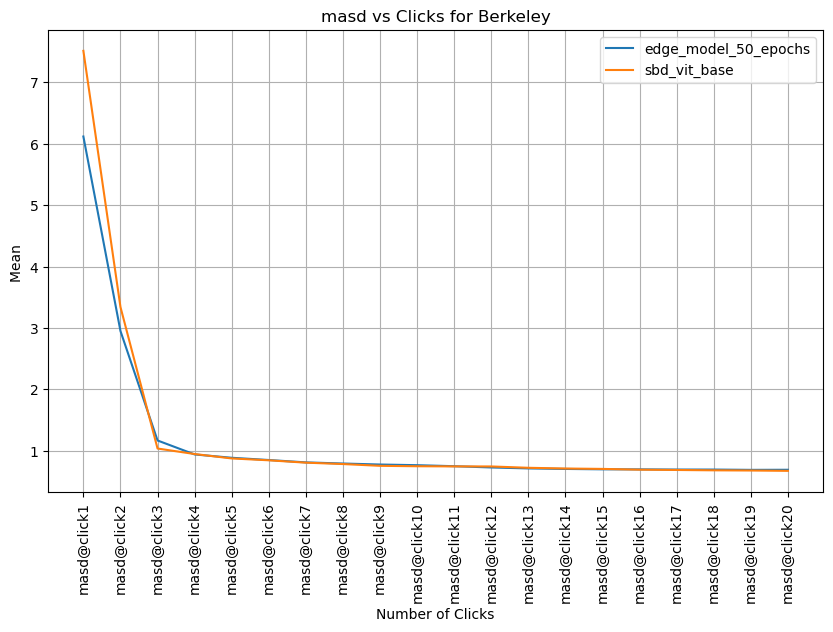

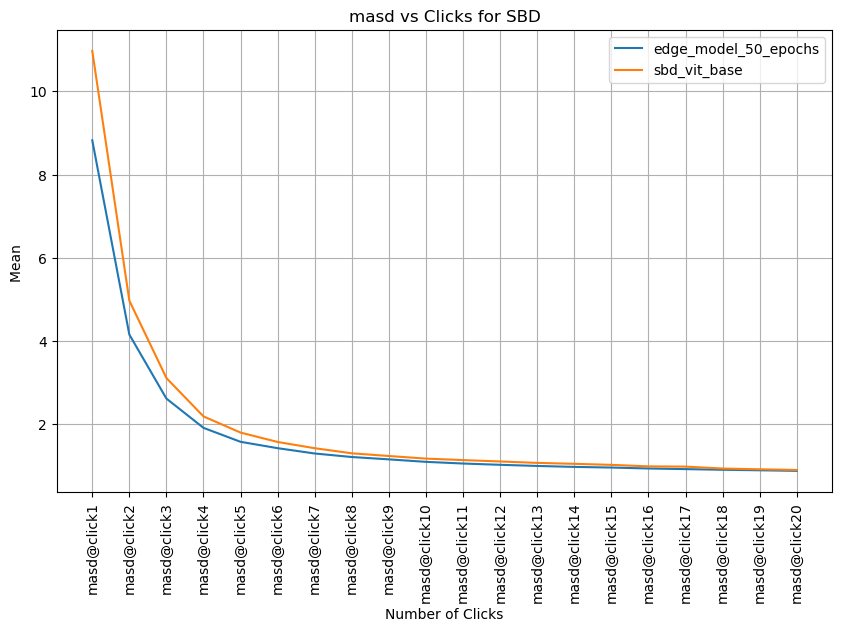

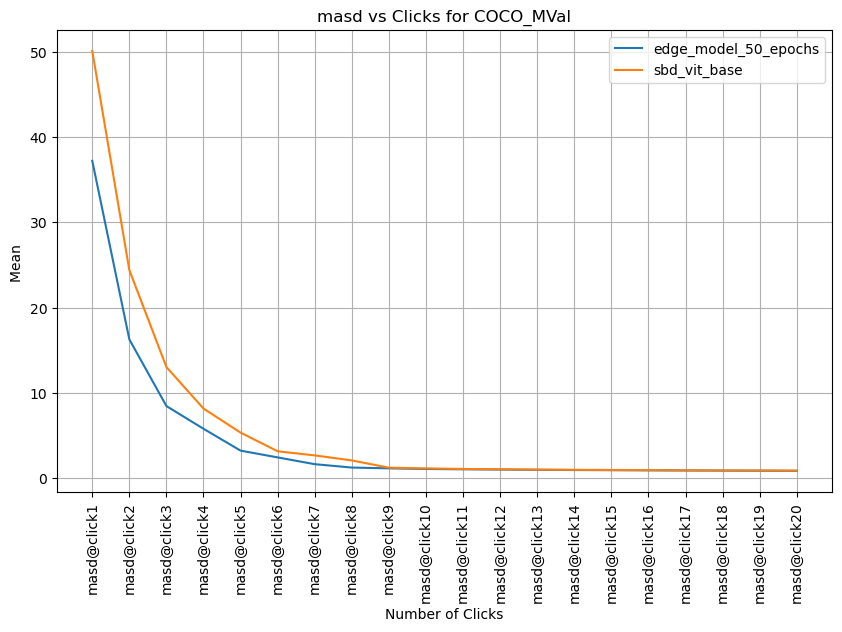

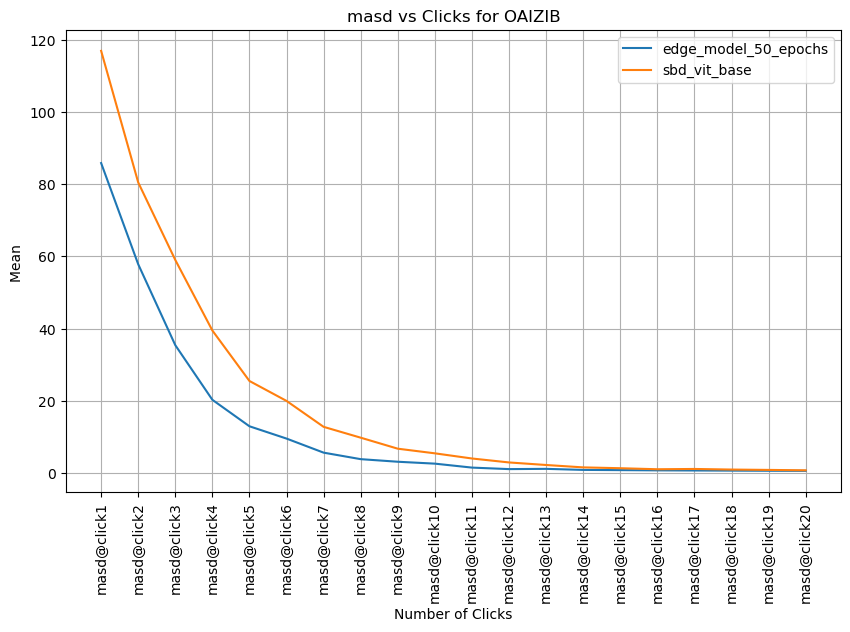

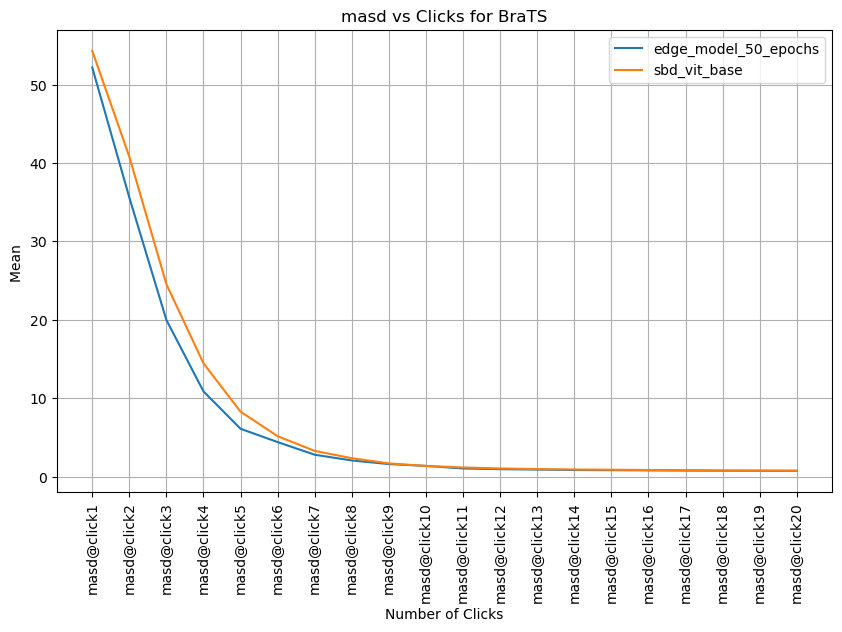

In [ ]:
# Get unique dataset names
#datasets = df_results_final.index.get_level_values(0).unique()
plot(df_results_final_asd,datasets,metric_type)

#### Normalised Surface Dice(NSD)

In [45]:
iou_type="nsds"
nsd_df,nsd = iou_analysis('./base_model',iou_type)
df_results_nsd, df_results_final_nsd = process_iou_analysis(nsd,iou_type)
df_results_nsd


Processing model: edge_model_50_epochs
Processing dataset: Berkeley, file: ./base_model/edge_model_50_epochs/metric_analysis/nsds/Berkeley_cvpr_NoBRS_20_nsds.pickle
Saved mean IOUs for Berkeley in model edge_model_50_epochs
Processing dataset: BraTS, file: ./base_model/edge_model_50_epochs/metric_analysis/nsds/BraTS_cvpr_NoBRS_20_nsds.pickle
Saved mean IOUs for BraTS in model edge_model_50_epochs
Processing dataset: OAIZIB, file: ./base_model/edge_model_50_epochs/metric_analysis/nsds/OAIZIB_cvpr_NoBRS_20_nsds.pickle
Saved mean IOUs for OAIZIB in model edge_model_50_epochs
Processing dataset: PascalVOC, file: ./base_model/edge_model_50_epochs/metric_analysis/nsds/PascalVOC_cvpr_NoBRS_20_nsds.pickle
Saved mean IOUs for PascalVOC in model edge_model_50_epochs
Processing dataset: COCO_MVal, file: ./base_model/edge_model_50_epochs/metric_analysis/nsds/COCO_MVal_cvpr_NoBRS_20_nsds.pickle
Saved mean IOUs for COCO_MVal in model edge_model_50_epochs
Processing dataset: GrabCut, file: ./base_mo

mnsd@click1  mnsd@click2  mnsd@click3  \
Model                Dataset                                            
edge_model_50_epochs Berkeley      0.561935     0.667154     0.707089   
                     BraTS         0.038714     0.079264     0.161276   
                     OAIZIB        0.032708     0.148532     0.256334   
                     PascalVOC     0.328622     0.368422     0.383010   
                     COCO_MVal     0.312969     0.447900     0.526700   
                     GrabCut       0.463663     0.517476     0.537239   
                     DAVIS         0.376779     0.509687     0.545150   
                     SBD           0.418223     0.553218     0.601946   
sbd_vit_base         Berkeley      0.540640     0.657800     0.710826   
                     BraTS         0.033098     0.056793     0.133440   
                     OAIZIB        0.006526     0.069177     0.136381   
                     PascalVOC     0.306446     0.352962     0.366496   
                     COCO_MVal     0.290927     0.413514     0.493770   
                     GrabCut       0.417997     0.491777     0.536593   
                     DAVIS         0.366321     0.496400     0.534156   
                     SBD           0.412094     0.538807     0.590258   

                                mnsd@click4  mnsd@click5  mnsd@click6  \
Model                Dataset                                            
edge_model_50_epochs Berkeley      0.733545     0.752353     0.764718   
                     BraTS         0.265222     0.363460     0.444769   
                     OAIZIB        0.339699     0.429299     0.501913   
                     PascalVOC     0.387890     0.390242     0.391061   
                     COCO_MVal     0.580351     0.617509     0.651354   
                     GrabCut       0.562549     0.585504     0.592421   
                     DAVIS         0.567835     0.588836     0.597700   
                     SBD           0.635016     0.658717     0.676521   
sbd_vit_base         Berkeley      0.732363     0.752787     0.765782   
                     BraTS         0.214890     0.310538     0.397773   
                     OAIZIB        0.215569     0.297848     0.362973   
                     PascalVOC     0.374073     0.378756     0.381100   
                     COCO_MVal     0.554982     0.598493     0.631270   
                     GrabCut       0.542702     0.567074     0.561167   
                     DAVIS         0.557712     0.574163     0.584239   
                     SBD           0.624394     0.649124     0.668482   

                                mnsd@click7  mnsd@click8  mnsd@click9  \
Model                Dataset                                            
edge_model_50_epochs Berkeley      0.780516     0.792389     0.800216   
                     BraTS         0.518664     0.576359     0.632247   
                     OAIZIB        0.558697     0.594804     0.652545   
                     PascalVOC     0.391979     0.392955     0.391700   
                     COCO_MVal     0.675333     0.697100     0.716189   
                     GrabCut       0.607144     0.633910     0.636536   
                     DAVIS         0.610037     0.620166     0.629490   
                     SBD           0.692159     0.705291     0.716050   
sbd_vit_base         Berkeley      0.784085     0.794560     0.805892   
                     BraTS         0.473101     0.533649     0.584540   
                     OAIZIB        0.430173     0.493980     0.546914   
                     PascalVOC     0.382383     0.384369     0.385187   
                     COCO_MVal     0.659932     0.681678     0.701292   
                     GrabCut       0.581701     0.600741     0.615048   
                     DAVIS         0.597218     0.609650     0.620777   
                     SBD           0.683711     0.697659     0.709402   

                                mnsd@click10  mnsd@click11  mnsd@click12  \
Model      

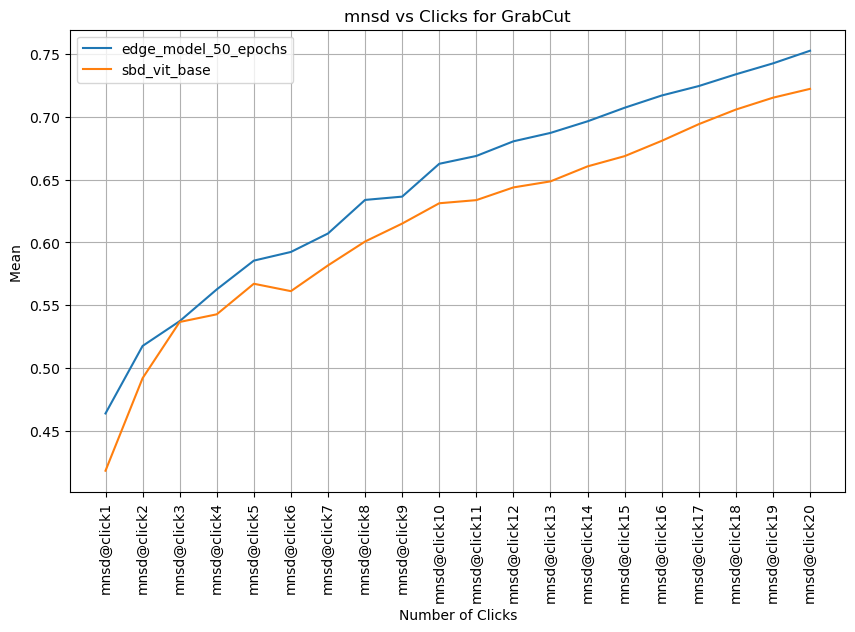

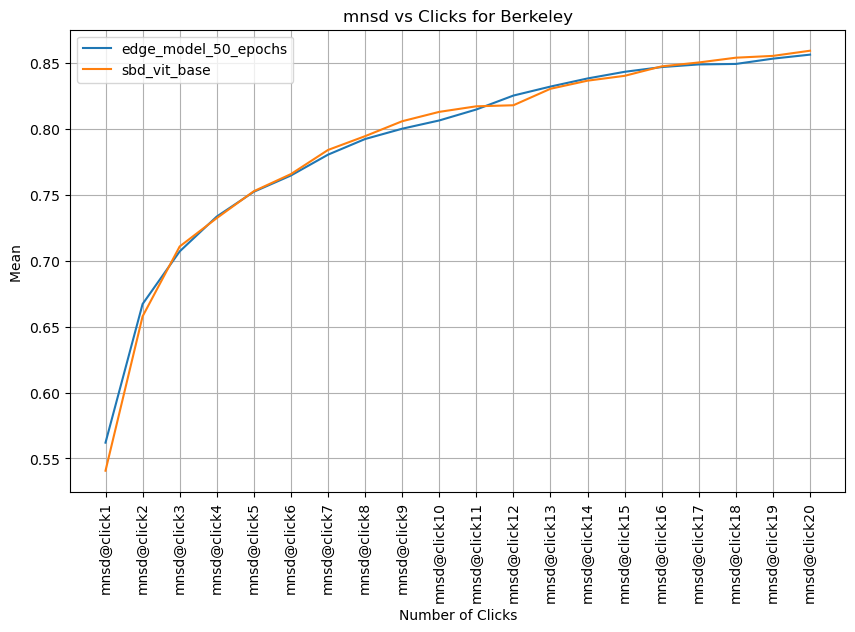

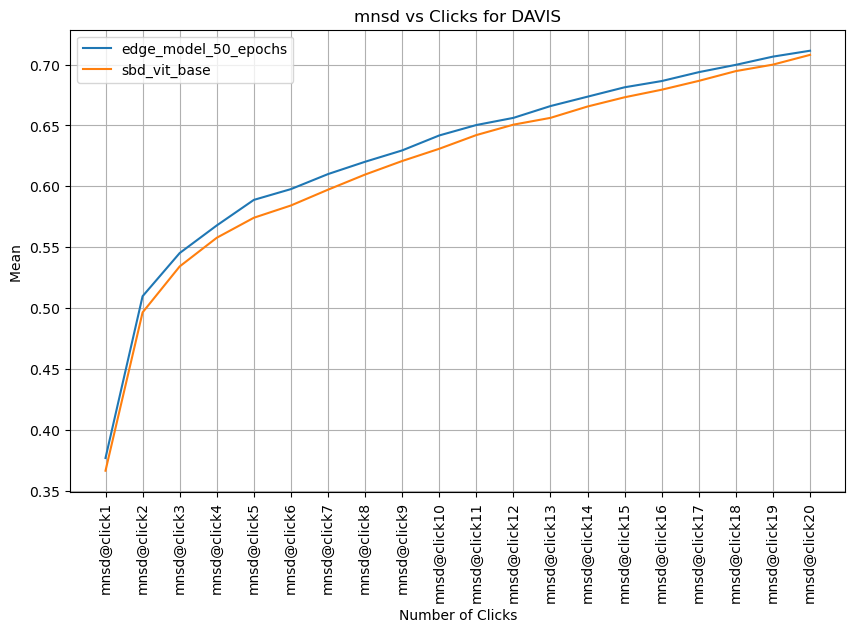

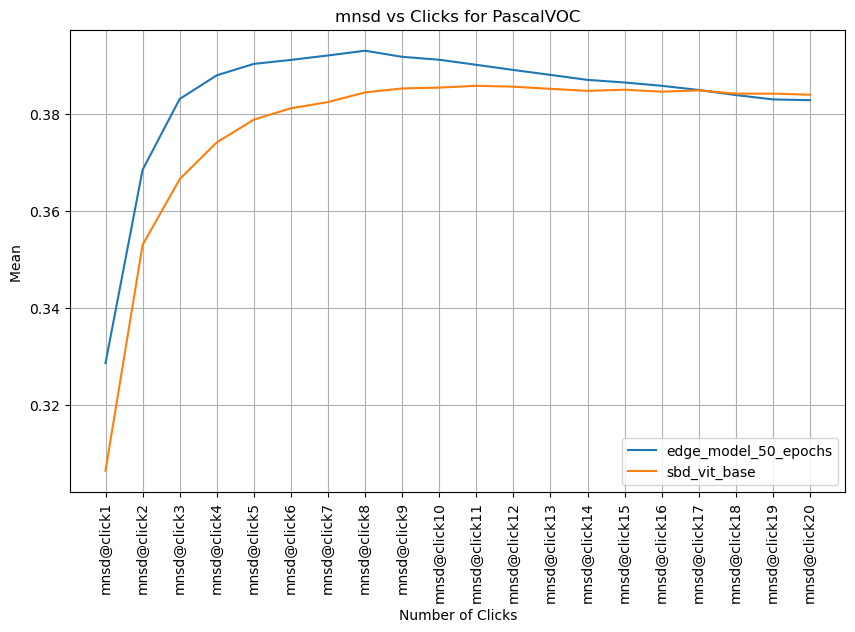

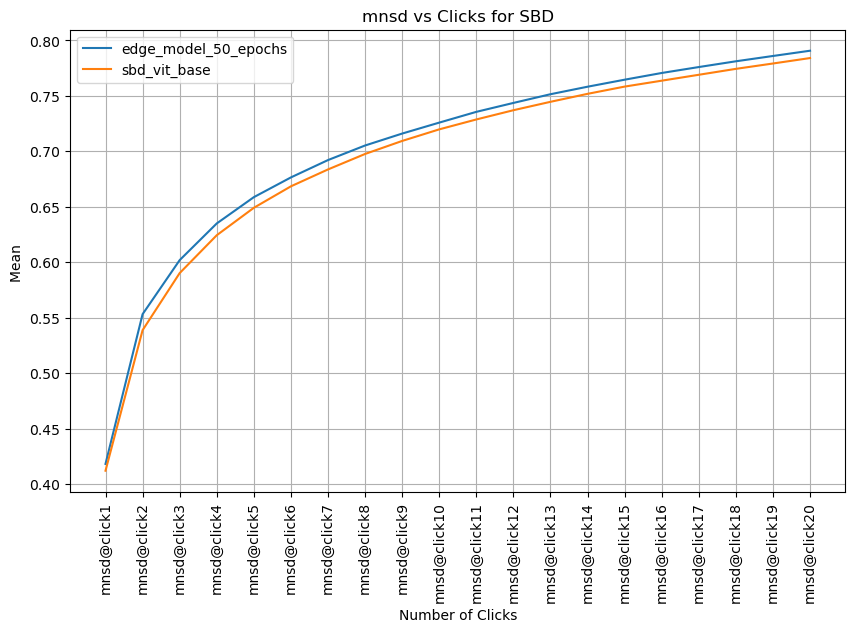

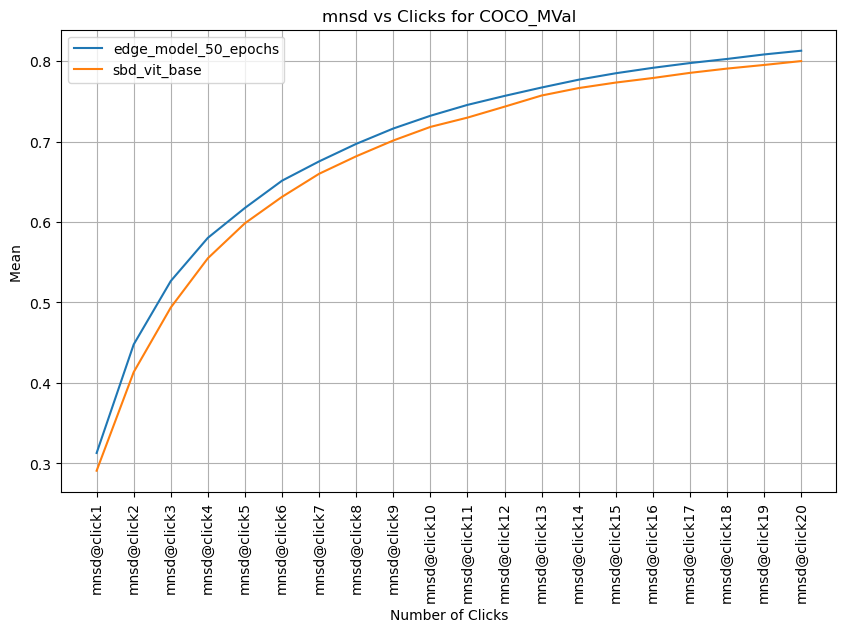

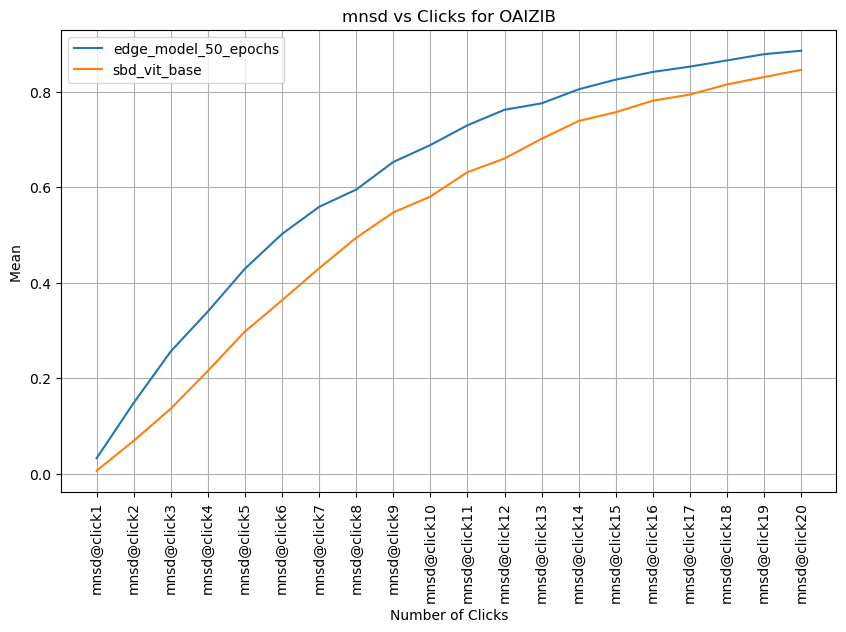

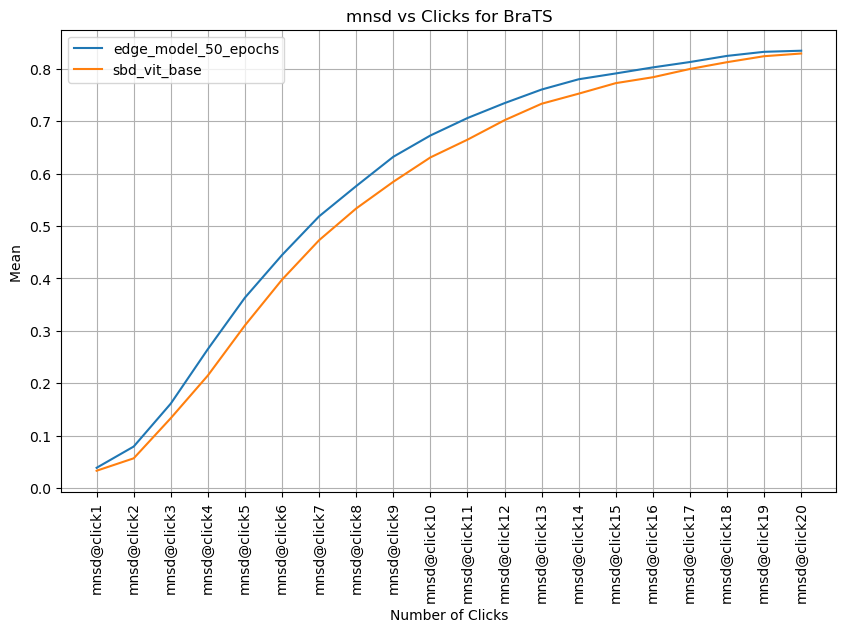

In [46]:
# Get unique dataset names
#datasets = df_results_final.index.get_level_values(0).unique()
plot(df_results_final_nsd,datasets,iou_type)